#**Predict Air Quality with Machine Learning**

Reference Notebook: https://www.sciencebuddies.org/science-fair-projects/project-ideas/

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler,RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import InputLayer, LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError, Huber
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

In [ ]:
#Load Drive
#from google.colab import drive
#drive.mount('/content/drive')

**Load Data**

In [79]:
csv_path = '/content/aqi_in1.csv'
df       = pd.read_csv(csv_path)
df.head()

,date,pm25,pm10,o3,no2,so2,co
0,2019-12-02,NaN,74.0,15.0,21.0,17.0,6.0
1,2019-12-03,85.0,82.0,24.0,12.0,2.0,8.0
2,2019-12-04,129.0,124.0,12.0,11.0,1.0,9.0
3,2019-12-05,170.0,114.0,23.0,21.0,1.0,8.0
4,2019-12-06,165.0,108.0,28.0,19.0,2.0,8.0


In [ ]:
#To add function files
#sys.path.append('/content/drive/MyDrive/Colab Notebooks')

In [80]:
##Functions Only
def getMeanStd(alist):
  #List of arrays or df columns
  mlist = []
  slist = []
  for i in alist:
    mlist.append(float(i.mean()))
    slist  .append(i.std())

  return (mlist,slist)

def makeXYfromdf(df, window_size):
    df.dropna(inplace=True)
    df_as_np = df.to_numpy()
    X = []
    y = []
    indexes = []

    numpoints = len(df_as_np)
    for i in range(numpoints - window_size):
        row = [[a] for a in df_as_np[i:i + window_size]]

        X.append(row)
        y_ = df_as_np[i + window_size]
        y.append(y_)
        indexes.append(df.index[i])

    return np.array(X), np.array(y), np.array(indexes)


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
def makeTrainTestAndScale(X,y,createVal=False):

    indices = np.arange(len(X))

    X_train, X_test, \
    y_train, y_test, \
    idx_train, idx_test = train_test_split(\
        X, y, indices, test_size=0.25, random_state=7
    )

    X_val, y_val, idx_val = 0,0,0
    if createVal:
        X_train, X_val,\
        y_train, y_val,\
        idx_train, idx_val = train_test_split(\
        X_train, y_train, idx_train, test_size=0.15, random_state=7
        )

    #scaler = MinMaxScaler()
    scaler = StandardScaler()
    #scaler = RobustScaler()

    X_train_flat = X_train.reshape(-1, 1)
    X_test_flat  = X_test.reshape(-1, 1)

    # Fit scaler on X_train_flat data and transform all flattened splits
    X_train_scaled_flat = scaler.fit_transform(X_train_flat)
    X_test_scaled_flat  = scaler.transform(X_test_flat)

    # Reshape back to original 3D shape
    X_train_scaled = X_train_scaled_flat.reshape(X_train.shape)
    X_test_scaled = X_test_scaled_flat.reshape(X_test.shape)


    X_val_scaled = 0
    if createVal:
      X_val_flat = X_val.reshape(-1, 1)
      X_val_scaled_flat = scaler.transform(X_val_flat)
      X_val_scaled = X_val_scaled_flat.reshape(X_val.shape)

    return X_train_scaled, y_train, idx_train, \
           X_test_scaled, y_test, idx_test,\
           X_val_scaled, y_val, idx_val



def getBestFitLine(x1,x2):
  #x1 = test, x2= pred
  model_lr = LinearRegression()
  x1_reshaped = np.array(x1).reshape(-1, 1)  # Reshape for fitting
  model_lr.fit(x1_reshaped, x2)
  best_fit = model_lr.predict(x1_reshaped)
  return best_fit


In [99]:
df2 = df.sort_values(by='date', inplace=False)
df2["date"] = pd.to_datetime(df2["date"], unit="ns")
df2 = df2.set_index("date")
df2['date'] = df2.index.date

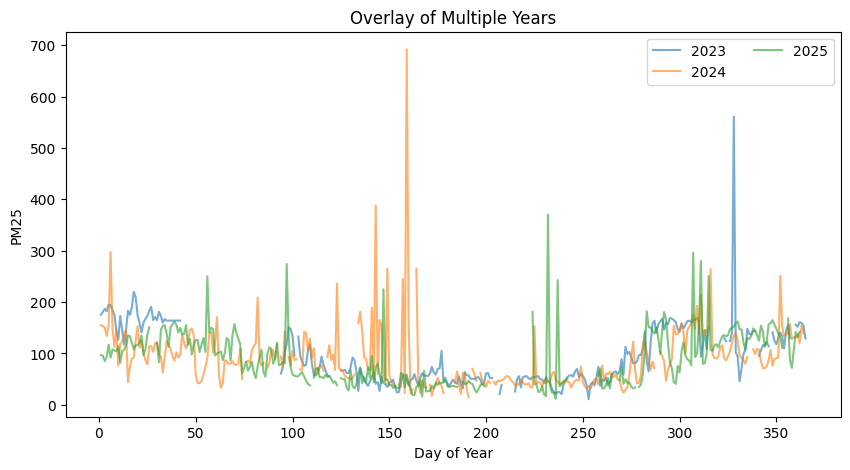

PM25: PM10
Mean: [116.2436676798379, 100.06301229508196]
STD:  [92.9335384705299, 107.46667977880168]


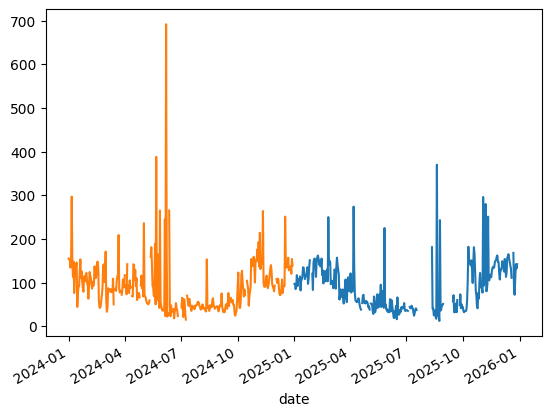

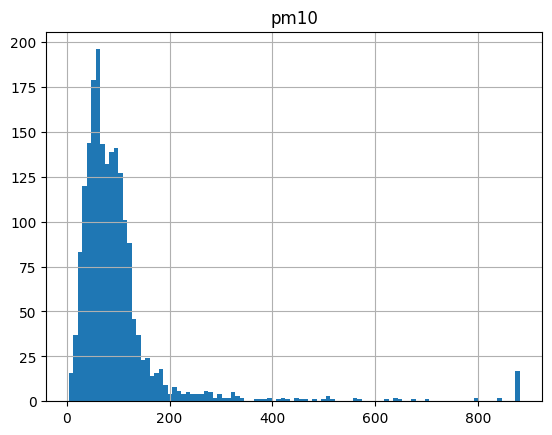

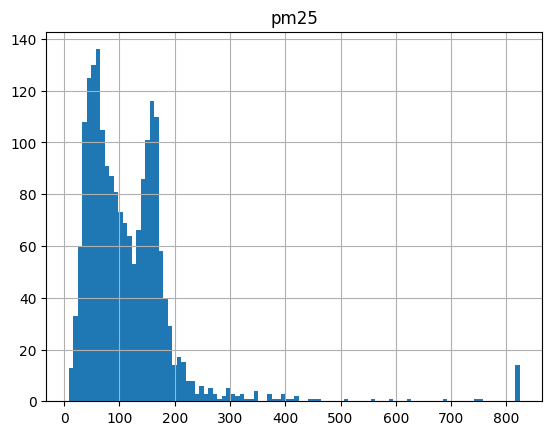

In [104]:
#Plot data and store in local variable
df_tmp1 = df2['2025-01-01':'2026-01-01'] # Filter Range
df_tmp2 = df2['2024-01-01':'2025-01-01'] # Filter Range
### To List
###l1 = df2.loc[(df["date"]>='2025-01-01') & (df['date']<'2026-01-01'),["pm25"]].to_numpy()
###l2 = df2.loc[(df["date"]>='2024-01-01') & (df['date']<'2025-01-01'),["pm25"]].to_numpy()

### Overlay ##
df2["year"] = df2.index.year
df2["doy"] = df2.index.dayofyear
daily = (
    df2.groupby(["year", "doy"])["pm25"]
      .mean()
      .reset_index()
)
fig, ax = plt.subplots(figsize=(10, 5))

for year, g in daily.groupby("year"):
    if year==2025 or year==2024 or year ==2023:
      ax.plot(g["doy"], g["pm25"], label=year, alpha=0.6)

ax.set_xlabel("Day of Year")
ax.set_ylabel("PM25")
ax.set_title("Overlay of Multiple Years")
ax.legend(ncol=2)
plt.show()
####


df_tmp1['pm25'].plot()
df_tmp2['pm25'].plot()

# #df['pm10'].plot()
df2.hist(column='pm10',bins=100)
df2.hist(column='pm25',bins=100)
mn_, sd_ = getMeanStd([df['pm25'],df['pm10']])
print ("PM25: PM10")
print("Mean:",mn_)
print("STD: ",sd_)
#-------
# Fit Data to pm25
pol = df2['pm25']


In [ ]:
#from aqi_fcns import *

In [122]:
window_size   = 60
X, y, indexes = makeXYfromdf(pol, window_size)

# Output the shapes of X and y to check the dimensions
print ("X, Y: ",X.shape, y.shape)


X, Y:  (1914, 60, 1) (1914,)


In [123]:
x_train, y_train, indexes_train,\
x_test, y_test,   indexes_test,\
x_val, y_val, indexes_val       = makeTrainTestAndScale(X,y,createVal=True)

In [124]:
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1219, 60, 1)
y_train shape: (1219,)
X_val shape: (216, 60, 1)
y_val shape: (216,)
X_test shape: (479, 60, 1)
y_test shape: (479,)


In [125]:
##Model
model = Sequential()
model.add(InputLayer(input_shape=(window_size, 1)))
# Add LSTM+Dense layers
model.add(LSTM(units=64, return_sequences=True, activation='relu'))
model.add(LSTM(units=40, return_sequences=False, activation='relu'))
model.add(Dense(40, activation='relu'))


# Add layer to  produce the predicted output (one value)
model.add(Dense(1, activation='linear'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 40)             │        16,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,377 (138.19 KB)

 Trainable params: 35,377 (138.19 KB)

 Non-trainable params: 0 (0.00 B)

In [175]:
#Compile ans save Once
cp1 = ModelCheckpoint('/content/aq_model1.keras', save_best_only=True)
#model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.004), metrics=[RootMeanSquaredError()])
model.compile(loss=Huber(delta=1.), optimizer=Adam(learning_rate=0.004), metrics=[RootMeanSquaredError()])

#And fit
model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, callbacks=[cp1],verbose=1)


#Compile and save Twice
model2 = tf.keras.models.load_model('/content/aq_model1.keras')
cp2 = ModelCheckpoint('/content/aq_model2.keras', save_best_only=True)
#model2.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.001), metrics=[RootMeanSquaredError()])
model2.compile(loss=Huber(delta=1.), optimizer=Adam(learning_rate=0.001), metrics=[RootMeanSquaredError()])
#And fit
model2.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=150, callbacks=[cp2],verbose=1)


Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 117.4375 - root_mean_squared_error: 234.5972 - val_loss: 141.0759 - val_root_mean_squared_error: 222.5195
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 110.9577 - root_mean_squared_error: 144.2162 - val_loss: 105.8033 - val_root_mean_squared_error: 146.1985
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 105.4903 - root_mean_squared_error: 136.7762 - val_loss: 103.4707 - val_root_mean_squared_error: 144.5677
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 102.1485 - root_mean_squared_error: 133.3540 - val_loss: 99.3779 - val_root_mean_squared_error: 141.7872
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 96.9343 - root_mean_squared_error: 126.5563 - val_loss: 90.5117 - val_root_mean_squared_error: 135.2406
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 80.3482 - root_mean_squared_error: 109.7971 - val_loss: 38.8596 - val_root_mean_squared_error: 92.3439
Epoch 7/30
39/39

In [176]:
##Check Predictions
model2_s = tf.keras.models.load_model('/content/aq_model2.keras')#saved model

y_pred = model2_s.predict(x_test).flatten()
y_t    = y_test

df2.index = pd.to_datetime(df2['date'])
df2.index.min()
start_date = pd.to_datetime(df2.index.min())
max_index  = indexes_test.max()
date_range = pd.date_range(start=start_date, periods=max_index + 1)
#print (start_date,max_index,date_range)

# Use the indices to select corresponding dates from the date range
date_index = date_range[indexes_test]

# Example data
data = {'Date': date_index, 'y_test': y_t, 'y_pred': y_pred}
df_pred = pd.DataFrame(data)

# # Set 'Date' as the index
df_pred.set_index('Date', inplace=True)

# # Sort the DataFrame by the index (Date) in ascending order
df_pred.sort_index(ascending=True, inplace=True)

#df_pred

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [177]:
np.array(range(0,10))

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Mean Absolute Error (MAE): 31.246248289040583
Mean Squared Error (MSE): 7584.968455891652


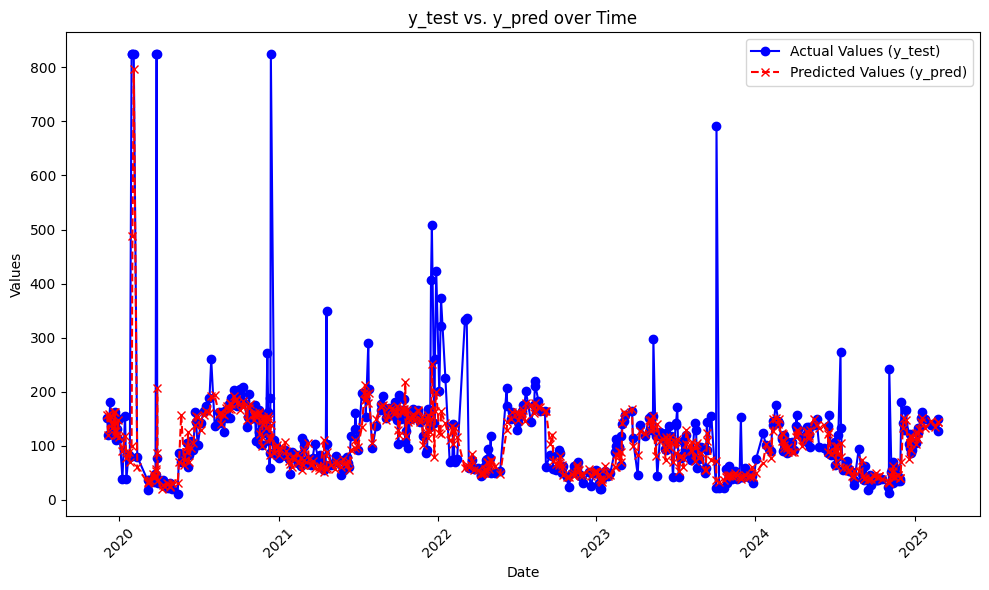

In [178]:
# Mean Squared Error (MSE)
mse = mean_squared_error(y_t, y_pred)
mae = mean_absolute_error(y_t, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")

###Plot Y Pred
plt.figure(figsize=(10, 6))
plt.plot(df_pred.index, df_pred['y_test'], label='Actual Values (y_test)', color='blue', marker='o')
plt.plot(df_pred.index, df_pred['y_pred'], label='Predicted Values (y_pred)', color='red', linestyle='--', marker='x')

# Customize the plot
plt.title('y_test vs. y_pred over Time')
plt.xlabel('Date')
plt.ylabel('Values')
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


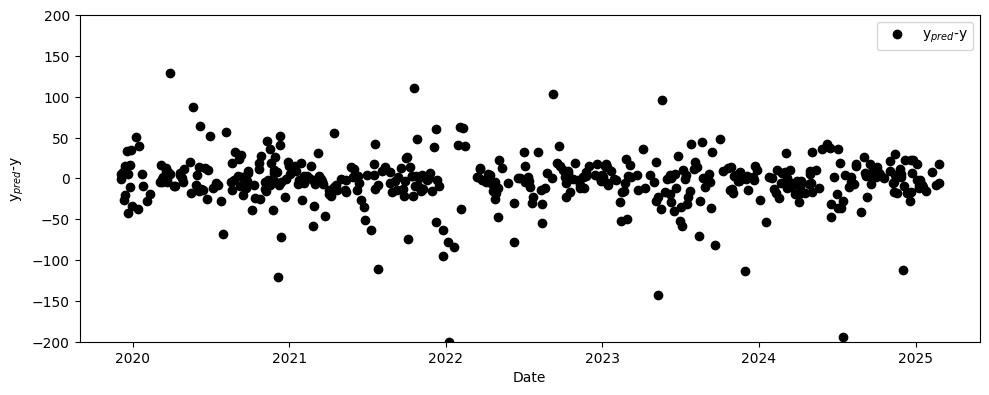

In [179]:
###Plot Residuals
plt.figure(figsize=(10, 4))
plt.plot(df_pred.index, (df_pred['y_pred']-df_pred['y_test']), label='y$_{pred}$-y', color='black', marker='o', linestyle='none')
plt.xlabel('Date')
plt.ylabel('y$_{pred}$-y')
plt.tight_layout()
plt.ylim(-200,200)
plt.legend()
plt.show()



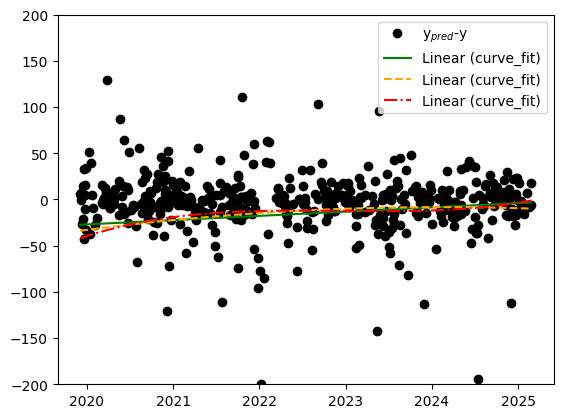

Line
--------------------
0     0.01
1     -9315.40
Quadratic
--------------------
0     -0.00
1     16.17
2     -5973160.64


In [180]:
x_vals   = df_pred.index.map(pd.Timestamp.toordinal)
y_vals   = (df_pred['y_pred']-df_pred['y_test']).to_numpy()

coeffs1 = np.polyfit(x_vals, y_vals, 1)  # degree 1 → Linear
y_linefit1 = np.polyval(coeffs1, x_vals)
coeffs2 = np.polyfit(x_vals, y_vals, 2)  # degree 2 → Quadratic
y_linefit2 = np.polyval(coeffs2, x_vals)
coeffs3 = np.polyfit(x_vals, y_vals, 3)  # degree 3 → cubic
y_linefit3 = np.polyval(coeffs3, x_vals)


plt.plot(df_pred.index, (df_pred['y_pred']-df_pred['y_test']), label='y$_{pred}$-y', color='black', marker='o', linestyle='none')
plt.plot(df_pred.index, y_linefit1, label="Linear (curve_fit)", color="green", linestyle='-')
plt.plot(df_pred.index, y_linefit2, label="Linear (curve_fit)", color="orange",linestyle='--')
plt.plot(df_pred.index, y_linefit3, label="Linear (curve_fit)", color="red",linestyle='-.')
plt.ylim(-200,200)
plt.legend()
plt.show()

def printCoeffs(cf,label):
  print (f"{label:s}")
  print (10*'--')

  for i,val in enumerate(cf):
    print(f"{i:}     {val:.2f}")


printCoeffs(coeffs1,'Line')
printCoeffs(coeffs2,'Quadratic')

##R2
# x_smooth = np.linspace(min(x), max(x), 200)
# y_pred = np.polyval(coeffs, x)
# residuals = y - y_pred
# ss_res = np.sum(residuals**2)
# ss_tot = np.sum((y - np.mean(y))**2)
# r2 = 1 - ss_res/ss_tot
# print("R^2:", r2)



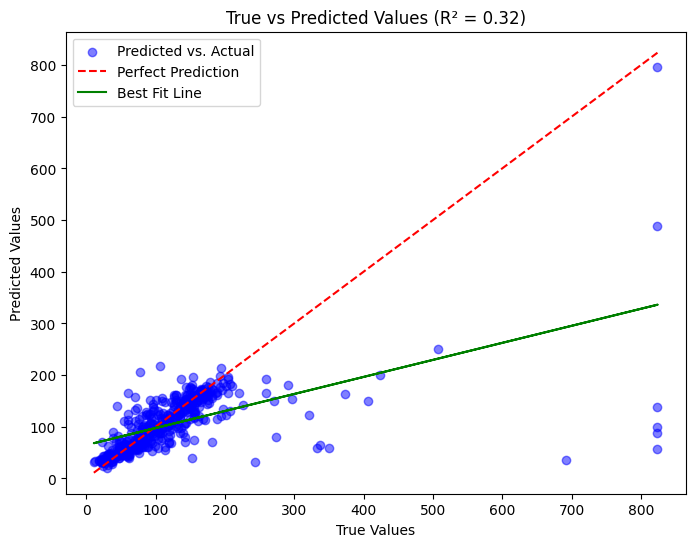

In [181]:
# Calculate R-squared
r2 = r2_score(y_t, y_pred)
y_best_fit = getBestFitLine(y_t,y_pred)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_t, y_pred, color='blue', alpha=0.5, label="Predicted vs. Actual")
plt.plot([y_t.min(), y_t.max()], [y_t.min(), y_t.max()], color='red', linestyle='--', label="Perfect Prediction")
plt.plot(y_t, y_best_fit, color='green', linestyle='-', label="Best Fit Line")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"True vs Predicted Values (R² = {r2:.2f})")
plt.legend()
plt.show()
#----



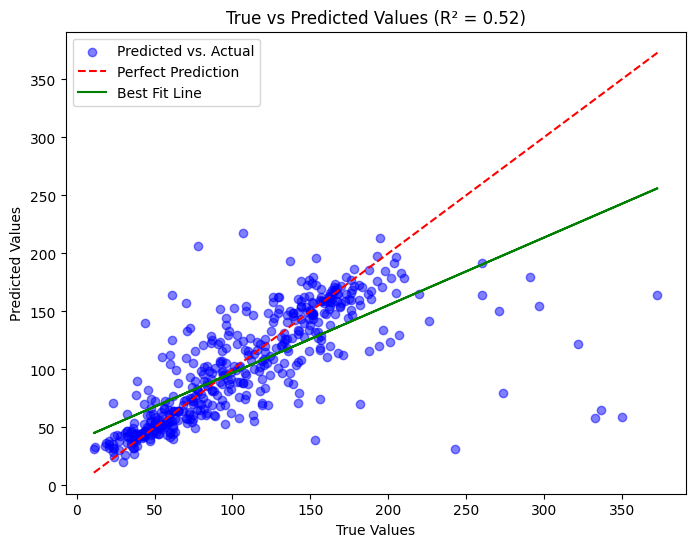

In [182]:
#Only the points less than 700
y_test.shape, y_pred.shape
df_plt = pd.DataFrame({"y_t": y_test,"y_pred": y_pred})
df_plt2= df_plt[df_plt['y_t']<400]
y_t2   = df_plt2["y_t"].to_numpy()
y_pred2= df_plt2['y_pred'].to_numpy()
r2 = r2_score(y_t2, y_pred2)
y_best_fit2 = getBestFitLine(y_t2,y_pred2)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_t2, y_pred2, color='blue', alpha=0.5, label="Predicted vs. Actual")
plt.plot([y_t2.min(), y_t2.max()], [y_t2.min(), y_t2.max()], color='red', linestyle='--', label="Perfect Prediction")
plt.plot(y_t2, y_best_fit2, color='green', linestyle='-', label="Best Fit Line")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"True vs Predicted Values (R² = {r2:.2f})")
plt.legend()
plt.show()